In [2]:
import os
import pandas as pd
from PIL import Image
from IPython.display import display

In [3]:
images_folder = input("Enter the path to the images folder: ").strip()
csv_path = "style_ar.csv"

Enter the path to the images folder:  C:\fashion-dataset\images


In [4]:
if not os.path.exists(csv_path):
    raise FileNotFoundError("CSV file not found!")

df = pd.read_csv(csv_path)

if 'description' not in df.columns:
    df['description'] = ""

print(f"Loaded CSV with {len(df)} rows.")
df.head()

Loaded CSV with 19544 rows.


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage,description
0,15970,رجالي,تياب,تياب قسم علوي,قمصان,كحلي,خريفي,كاجوال,قميص مربعات بألوان كحلي وأبيض وبني غامق. ياقته...
1,39386,رجالي,تياب,تياب قسم سفلي,جينزات,أزرق,صيفي,كاجوال,بنطلون جينز رجالي لونه كحلي غامق مع شوية تفتيح...
2,21379,رجالي,تياب,تياب قسم سفلي,بناطلين رياضة,أسود,خريفي,كاجوال,بنطلون رياضة قطن بينربط بمطاط عليه اشارة فريق ...
3,53759,رجالي,تياب,تياب قسم علوي,كنزات,رمادي,صيفي,كاجوال,NaN
4,1855,رجالي,تياب,تياب قسم علوي,كنزات,رمادي,صيفي,كاجوال,NaN


In [5]:
start_row = int(input(f"Enter the starting row number (0 to {len(df)-1}): "))
if start_row < 0 or start_row >= len(df):
    raise ValueError("Starting row out of range!")

print(f"Starting from row {start_row}")

Enter the starting row number (0 to 19543):  3


Starting from row 3


In [6]:
def display_image_inline(image_id, folder, max_width=400):
    for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.gif']:
        path = os.path.join(folder, str(image_id) + ext)
        if os.path.exists(path):
            img = Image.open(path)
            # Resize while keeping aspect ratio
            w_percent = (max_width / float(img.size[0]))
            h_size = int((float(img.size[1]) * float(w_percent)))
            img_resized = img.resize((max_width, h_size), resample=Image.Resampling.LANCZOS)
            
            display(img_resized)
            return True
    return False

Row 3 - Image ID: 53759


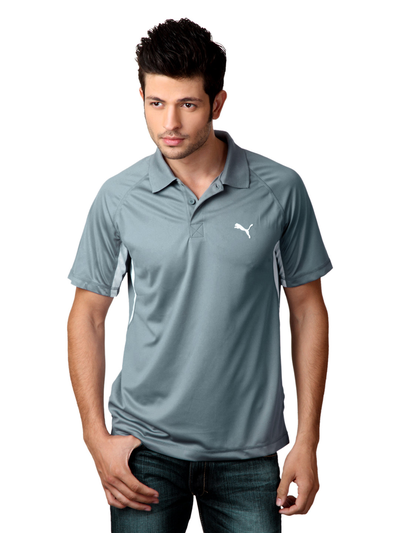

Enter description (or 'q' to quit):  q


Quitting early. Saving progress...


In [7]:
for idx in range(start_row, len(df)):
    row = df.iloc[idx]
    image_id = row['id']

    # Skip if description already exists and not empty
    if pd.notna(row['description']) and str(row['description']).strip() != "":
        print(f"Row {idx} - Image ID: {image_id} already has a description, skipping.")
        continue

    print(f"Row {idx} - Image ID: {image_id}")
    found = display_image_inline(image_id, images_folder)

    if not found:
        print("Image not found, skipping this row.\n")
        continue

    desc = input("Enter description (or 'q' to quit): ").strip()
    if desc.lower() == 'q':
        print("Quitting early. Saving progress...")
        df.to_csv(csv_path, index=False)
        break

    if desc:
        df.at[idx, 'description'] = desc
        df.to_csv(csv_path, index=False)
        print(f"Saved description for row {idx}\n")
    else:
        print("No description entered. Moving on...\n")